# Teste de Baseline com regressão linear para predição de resistência à compressão

In [1]:
%%capture
!pip install optuna

In [2]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
import matplotlib.pyplot as plt
from google.colab import drive
from tqdm.notebook import tqdm
from scipy import stats
import seaborn as sns
import pandas as pd
import numpy as np
import os, optuna

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'

# Regressão linear simples
simples_file = 'df_resistencia_RL.pkl'
simples_path = os.path.join(dirpath, simples_file)

df_simples = pd.read_pickle(simples_path)
df_simples['target'] = df_simples['Resistencia_Compressao_MPa'].copy()
df_simples.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])

# Regressão linear Lasso
lasso_file = 'df_resistencia_Lasso.pkl'
lasso_path = os.path.join(dirpath, lasso_file)

df_lasso = pd.read_pickle(lasso_path)
df_lasso['target'] = df_lasso['Resistencia_Compressao_MPa'].copy()
df_lasso.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])

# Regressão linear Ridge
ridge_file = 'df_resistencia_Ridge.pkl'
ridge_path = os.path.join(dirpath, ridge_file)

df_ridge = pd.read_pickle(ridge_path)
df_ridge['target'] = df_ridge['Resistencia_Compressao_MPa'].copy()
df_ridge.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])

# Regressão linear ElasticNet
elasticnet_file = 'df_resistencia_ElasticNet.pkl'
elasticnet_path = os.path.join(dirpath, elasticnet_file)

df_elasticnet = pd.read_pickle(elasticnet_path)
df_elasticnet['target'] = df_elasticnet['Resistencia_Compressao_MPa'].copy()
df_elasticnet.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])

In [5]:
df_simples.shape, df_lasso.shape, df_ridge.shape, df_elasticnet.shape

((533, 25), (533, 11), (533, 23), (533, 22))

## Teste com Regressão simples

In [6]:
n_groups = df_simples['Autores/ano'].nunique()
print(f"Número de grupos únicos (Autores/ano): {n_groups}")
gkf = GroupKFold(n_splits=n_groups)

Número de grupos únicos (Autores/ano): 16


In [7]:
all_preds = []
all_true = []
all_groups = []

X = df_simples.drop(
    columns=["target", "Autores/ano"]
)

y = df_simples["target"]
groups = df_simples["Autores/ano"]

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = LinearRegression()

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    all_preds.extend(preds)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])

In [8]:
lr_results = pd.DataFrame({
    "y_true": all_true,
    "y_pred": all_preds,
    "group": all_groups
})

lr_results["residual"] = (
    lr_results["y_true"] -
    lr_results["y_pred"]
)

lr_results["abs_error"] = (
    lr_results["residual"].abs()
)

## Observado vs Predito

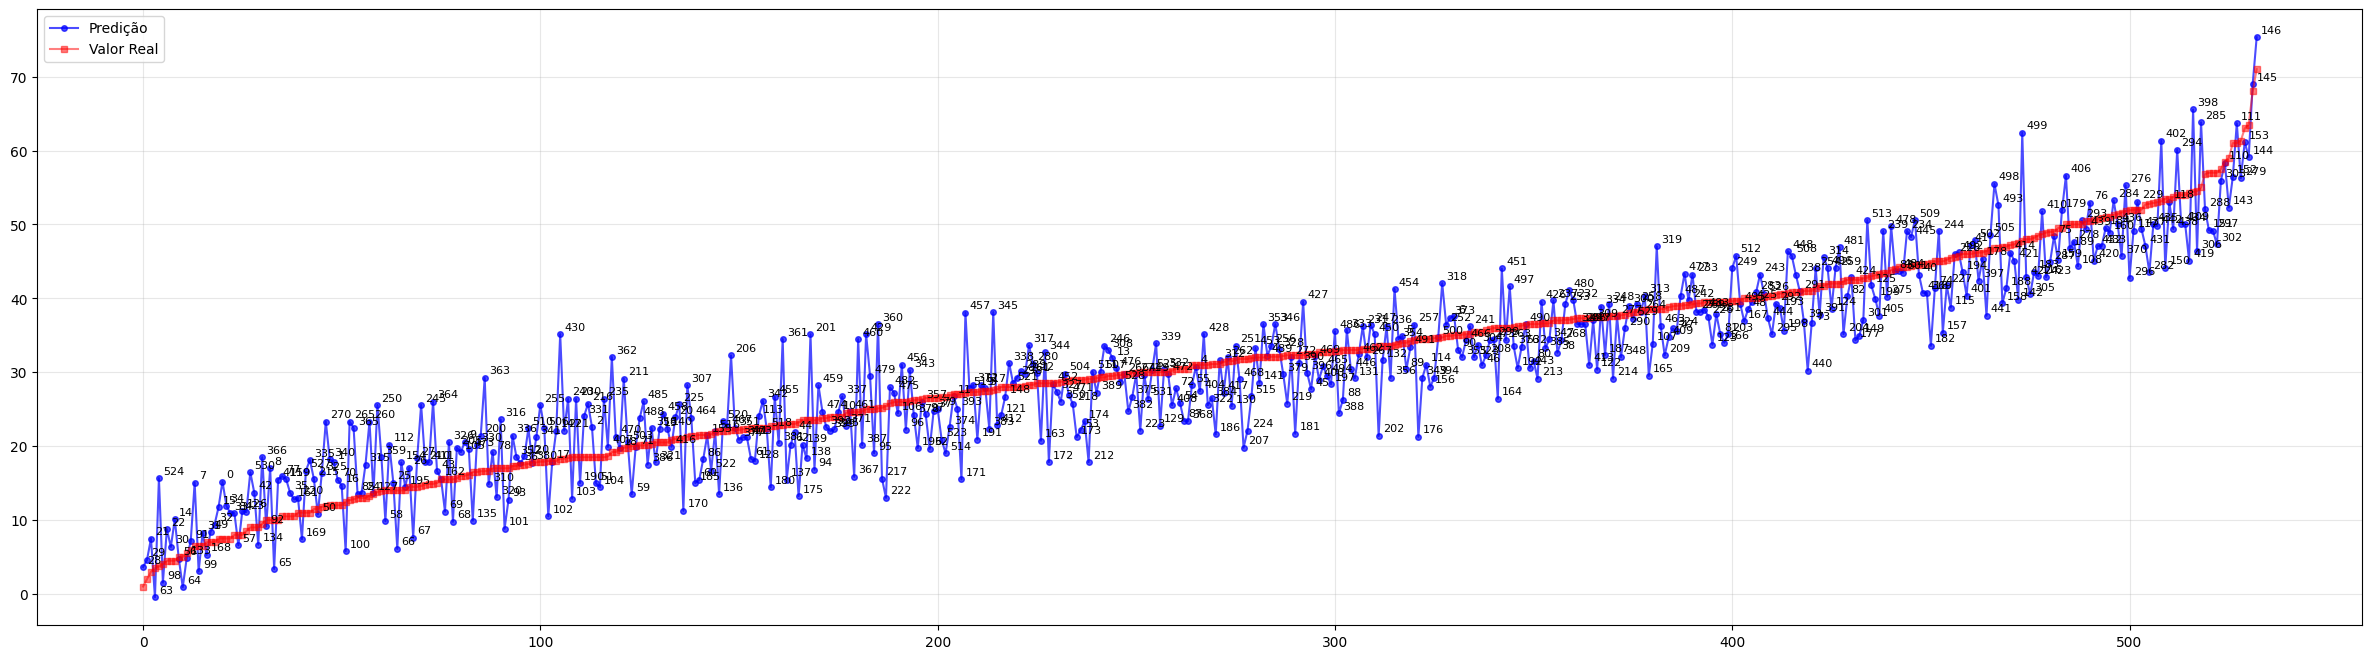

In [9]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = lr_results.sort_values(by="y_true")
indices = range(len(debug_df))

plt.figure(figsize=(30, 8))

plt.plot(
    indices,
    debug_df["y_pred"],
    color='blue',
    label="Predição",
    alpha=0.7,
    linewidth=1.5,
    marker='o',
    markersize=4
)

plt.plot(
    indices,
    debug_df["y_true"],
    color='red',
    label="Valor Real",
    alpha=0.5,
    linewidth=1.5,
    marker='s',
    markersize=4
)

for x, y, idx in zip(
    indices,
    debug_df["y_pred"],
    debug_df.index
):
    plt.annotate(
        str(idx),
        (x, y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Distribuição dos residuos

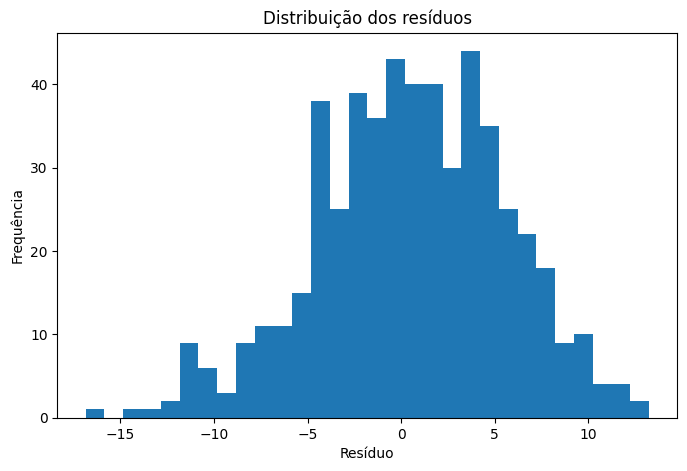

In [10]:
plt.figure(figsize=(8,5))

plt.hist(
    lr_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

## Residuo vs Predito

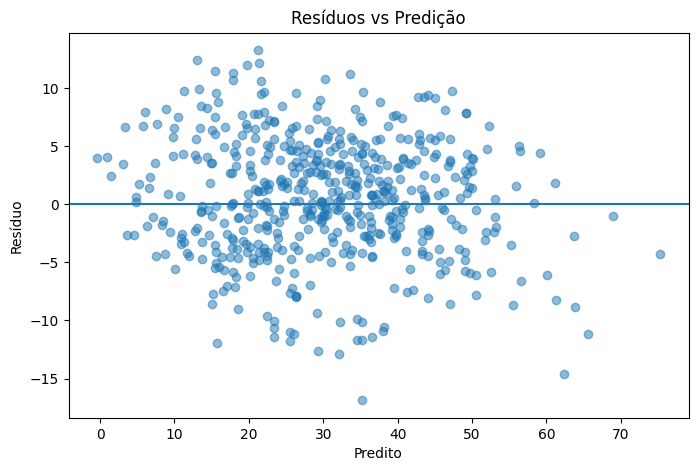

In [11]:
plt.figure(figsize=(8,5))

plt.scatter(
    lr_results["y_pred"],
    lr_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

## Erro Medio por grupo

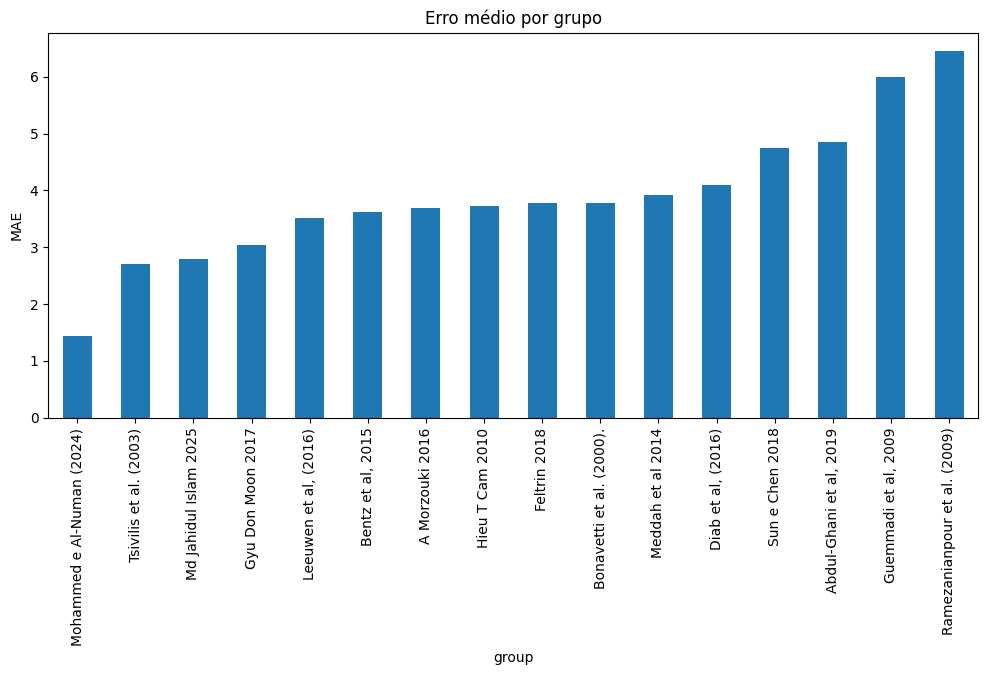

In [12]:
group_errors = (
    lr_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [13]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 5.1065
mean_absolute_error: 4.0914
mean_absolute_percentage_error: 0.1918
R² Score: 85.3625


# Teste com regressão Lasso

In [14]:
X = df_lasso.drop(
    columns=["target", "Autores/ano"]
)

y = df_lasso["target"]
groups = df_lasso["Autores/ano"]

def objective(trial):
    rmse_scores = []

    alpha = trial.suggest_float("alpha", 0.01, 10)

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        model = Lasso(alpha=alpha, random_state=42)

        model.fit(X_train, y_train)

        preds = model.predict(X_val)

        rmse = root_mean_squared_error(y_val, preds)
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)


In [15]:
# ==========================================
# EXECUTANDO O ESTUDO
# ==========================================
n_trials = 250

pbar = tqdm(total=n_trials, desc="Otimizando Regressão Lasso")

def tqdm_callback(study, trial):
    pbar.update(1)
    pbar.set_postfix({
        "best_rmse": f"{study.best_value:.4f}"
    })

study_lasso = optuna.create_study(
    direction="minimize",
    study_name="Tuning_Concreto"
)

study_lasso.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[tqdm_callback]
)

pbar.close()

print(f"Melhor RMSE alcançado (Cross-Validation): {study_lasso.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study_lasso.best_params.items():
    print(f"  '{key}': {value},")

Otimizando Regressão Lasso:   0%|          | 0/250 [00:00<?, ?it/s]

[I 2026-06-11 13:47:54,796] A new study created in memory with name: Tuning_Concreto
[I 2026-06-11 13:47:54,915] Trial 0 finished with value: 10.318837963498055 and parameters: {'alpha': 9.421837278771122}. Best is trial 0 with value: 10.318837963498055.
[I 2026-06-11 13:47:55,035] Trial 1 finished with value: 6.037625812087267 and parameters: {'alpha': 2.079093672211139}. Best is trial 1 with value: 6.037625812087267.
[I 2026-06-11 13:47:55,156] Trial 2 finished with value: 7.103803347578054 and parameters: {'alpha': 4.581382221989677}. Best is trial 1 with value: 6.037625812087267.
[I 2026-06-11 13:47:55,266] Trial 3 finished with value: 6.686239800227533 and parameters: {'alpha': 3.8316683886548057}. Best is trial 1 with value: 6.037625812087267.
[I 2026-06-11 13:47:55,385] Trial 4 finished with value: 5.620965729398922 and parameters: {'alpha': 0.06031148148336944}. Best is trial 4 with value: 5.620965729398922.
[I 2026-06-11 13:47:55,514] Trial 5 finished with value: 5.63479699946

Melhor RMSE alcançado (Cross-Validation): 5.4697
Melhores Hiperparâmetros encontrados:
  'alpha': 0.151939946448674,


In [16]:
all_preds = []
all_true = []
all_groups = []

X = df_lasso.drop(
    columns=["target", "Autores/ano"]
)

y = df_lasso["target"]
groups = df_lasso["Autores/ano"]

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = Lasso(alpha=study_lasso.best_params["alpha"], random_state=42)

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    all_preds.extend(preds)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])

In [17]:
lasso_results = pd.DataFrame({
    "y_true": all_true,
    "y_pred": all_preds,
    "group": all_groups
})

lasso_results["residual"] = (
    lasso_results["y_true"] -
    lasso_results["y_pred"]
)

lasso_results["abs_error"] = (
    lasso_results["residual"].abs()
)

## Observado vs Predito

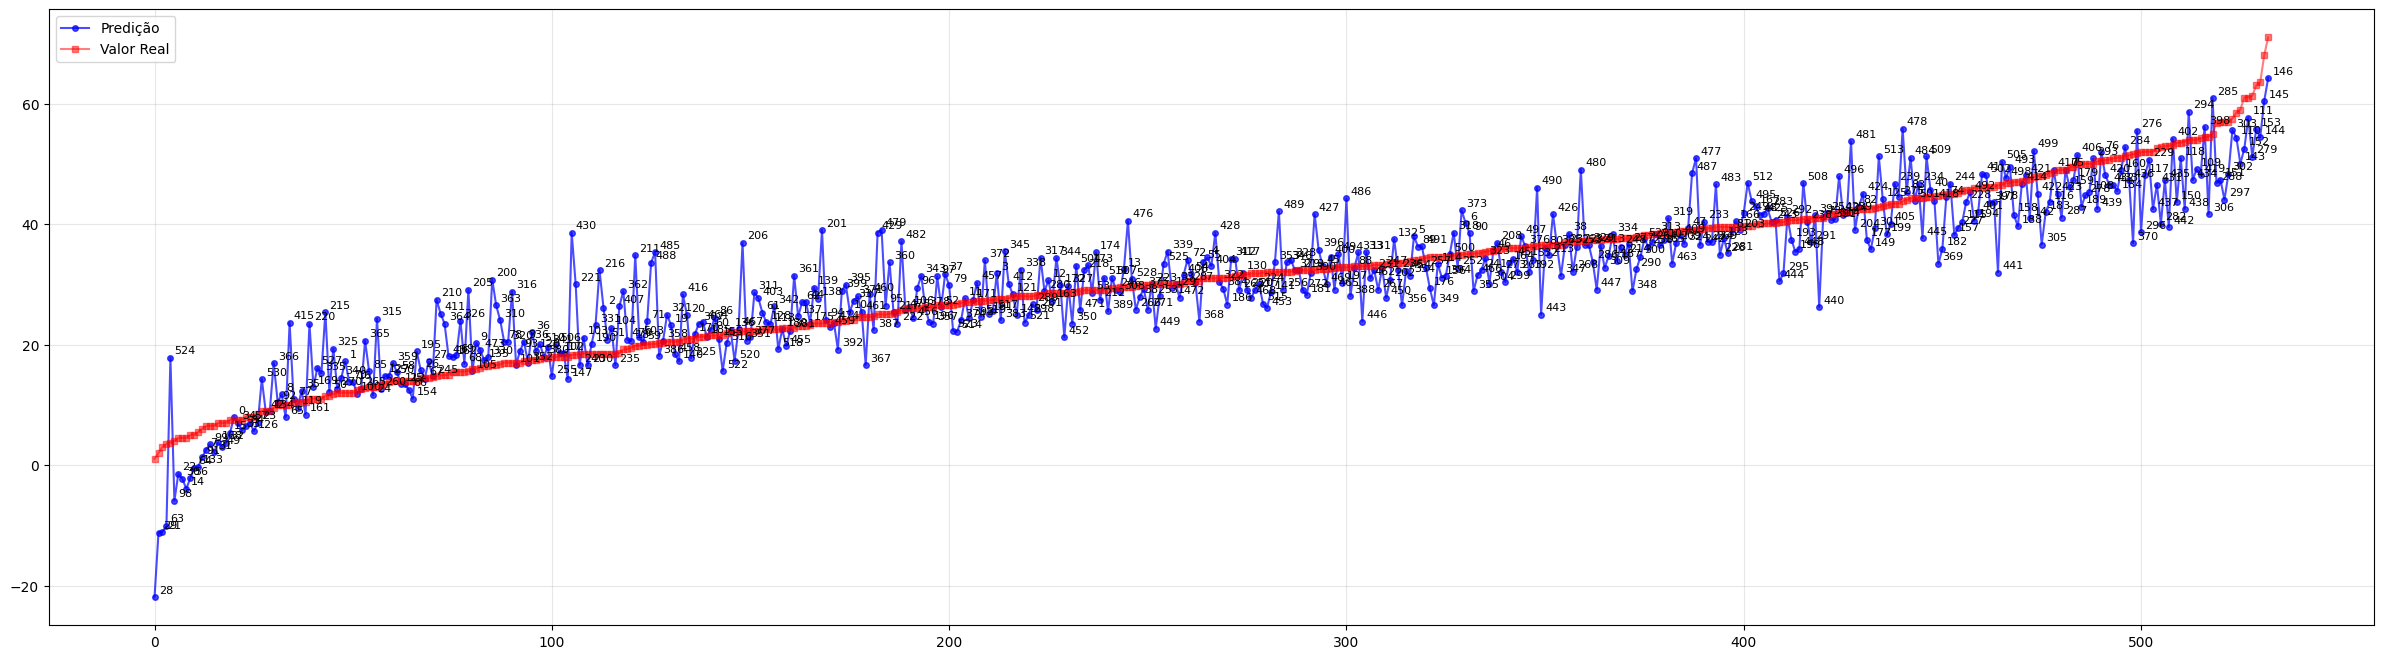

In [18]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = lasso_results.sort_values(by="y_true")
indices = range(len(debug_df))

plt.figure(figsize=(30, 8))

plt.plot(
    indices,
    debug_df["y_pred"],
    color='blue',
    label="Predição",
    alpha=0.7,
    linewidth=1.5,
    marker='o',
    markersize=4
)

plt.plot(
    indices,
    debug_df["y_true"],
    color='red',
    label="Valor Real",
    alpha=0.5,
    linewidth=1.5,
    marker='s',
    markersize=4
)

for x, y, idx in zip(
    indices,
    debug_df["y_pred"],
    debug_df.index
):
    plt.annotate(
        str(idx),
        (x, y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Distribuição dos residuos

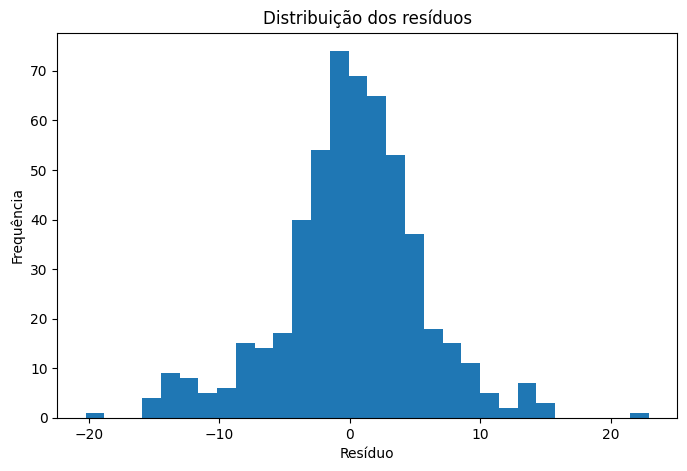

In [19]:
plt.figure(figsize=(8,5))

plt.hist(
    lasso_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

## Residuo vs Predito

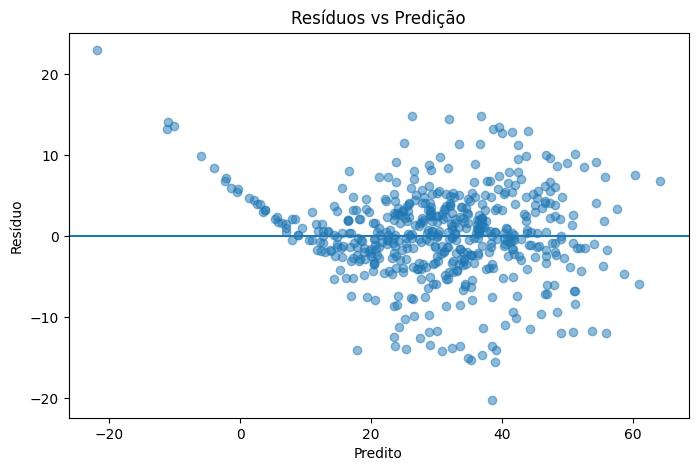

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(
    lasso_results["y_pred"],
    lasso_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

## Erro Medio por grupo

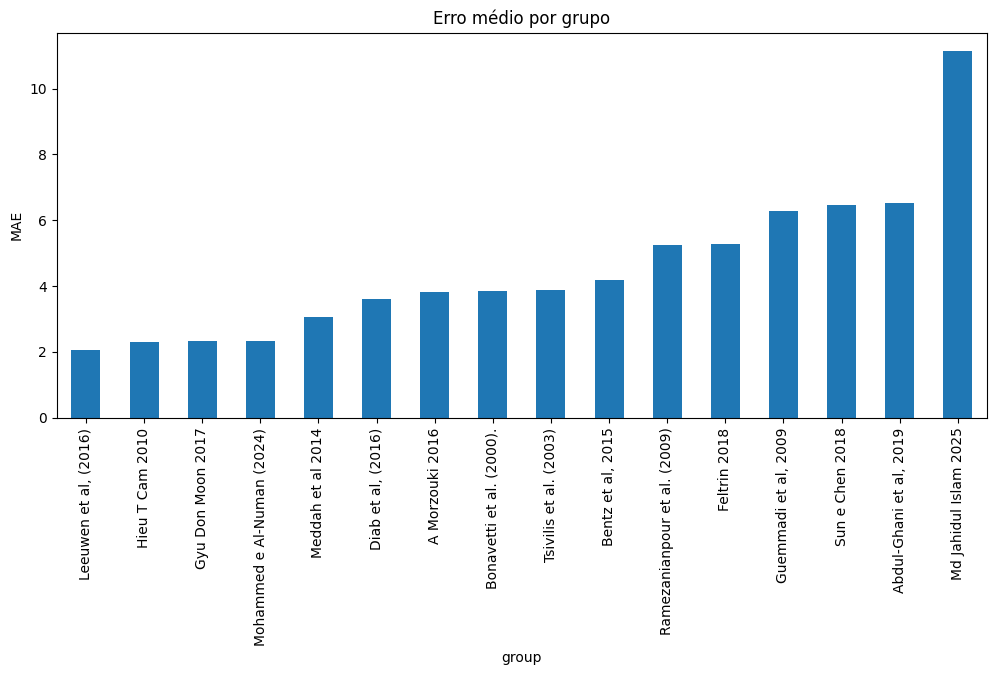

In [21]:
group_errors = (
    lasso_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [22]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 5.4765
mean_absolute_error: 4.0261
mean_absolute_percentage_error: 0.2461
R² Score: 83.1644


## Teste com regressão Ridge

In [23]:
X = df_ridge.drop(
    columns=["target", "Autores/ano"]
)

y = df_ridge["target"]
groups = df_ridge["Autores/ano"]

def objective(trial):
    rmse_scores = []

    alpha = trial.suggest_float("alpha", 0.01, 1000)

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        scaler_train = StandardScaler()

        X_train = scaler_train.fit_transform(X_train)
        X_val = scaler_train.transform(X_val)

        model = Ridge(alpha=alpha, random_state=42)

        model.fit(X_train, y_train)

        preds = model.predict(X_val)

        rmse = root_mean_squared_error(y_val, preds)
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)


In [24]:
# ==========================================
# EXECUTANDO O ESTUDO
# ==========================================
n_trials = 250

pbar = tqdm(total=n_trials, desc="Otimizando Regressão Ridge")

def tqdm_callback(study, trial):
    pbar.update(1)
    pbar.set_postfix({
        "best_rmse": f"{study.best_value:.4f}"
    })

study_ridge = optuna.create_study(
    direction="minimize",
    study_name="Tuning_Concreto"
)

study_ridge.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[tqdm_callback]
)

pbar.close()

print(f"Melhor RMSE alcançado (Cross-Validation): {study_ridge.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study_ridge.best_params.items():
    print(f"  '{key}': {value},")

Otimizando Regressão Ridge:   0%|          | 0/250 [00:00<?, ?it/s]

[I 2026-06-11 13:48:32,035] A new study created in memory with name: Tuning_Concreto
[I 2026-06-11 13:48:32,166] Trial 0 finished with value: 6.7505612201341965 and parameters: {'alpha': 271.47126122937203}. Best is trial 0 with value: 6.7505612201341965.
[I 2026-06-11 13:48:32,279] Trial 1 finished with value: 6.755595938639466 and parameters: {'alpha': 177.2783959301783}. Best is trial 0 with value: 6.7505612201341965.
[I 2026-06-11 13:48:32,388] Trial 2 finished with value: 6.764204137153104 and parameters: {'alpha': 304.21031689995056}. Best is trial 0 with value: 6.7505612201341965.
[I 2026-06-11 13:48:32,491] Trial 3 finished with value: 7.085139536819982 and parameters: {'alpha': 646.9780717244888}. Best is trial 0 with value: 6.7505612201341965.
[I 2026-06-11 13:48:32,611] Trial 4 finished with value: 6.792127921951032 and parameters: {'alpha': 349.9409504705749}. Best is trial 0 with value: 6.7505612201341965.
[I 2026-06-11 13:48:32,721] Trial 5 finished with value: 6.88054371

Melhor RMSE alcançado (Cross-Validation): 5.6572
Melhores Hiperparâmetros encontrados:
  'alpha': 0.3556808835773201,


In [25]:
all_instances = []

X = df_ridge.drop(
    columns=["target", "Autores/ano"]
)

y = df_ridge["target"]
groups = df_ridge["Autores/ano"]

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = Ridge(alpha=study_ridge.best_params["alpha"], random_state=42)

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    fold_results = df_ridge.iloc[val_idx].copy()

    fold_results["y_true"] = y_val.values
    fold_results["y_pred"] = preds
    fold_results["error"] = (
        fold_results["y_true"] - fold_results["y_pred"]
    )
    fold_results["abs_error"] = (
        fold_results["error"].abs()
    )
    fold_results["group"] = groups.iloc[val_idx].values

    all_instances.append(fold_results)

In [26]:
all_instances[0].columns

Index(['Finura_Cimento_Blaine_m2_kg', 'Agregado_Graudo_Total_kg_m3',
       'Relacao_Agua_Cimento', 'Tipo_Molde_Cod', 'cod_classe',
       'Massa_Esp_Cimento_kg_m3', 'Massa_Esp_Brita_kg_m3',
       'Massa_Esp_Filer_kg_m3', 'porosidade_volumetrica_inicial',
       'vol_po_total', 'pasta_agregado', 'indice_conformidade_feret',
       'pow_interacao_tempo', 'hasselman_cinetico', 's_fib',
       'pasta_agregado_fino', 'densidade_matriz', 'Autores/ano', 'vol_cimento',
       'vol_filer', 'Relacao_Agua_Aglomerante', 'vol_sp', 'target', 'y_true',
       'y_pred', 'error', 'abs_error', 'group'],
      dtype='object')

In [27]:
ridge_results = pd.concat(all_instances, ignore_index=True)

debug_df['error'] = (
    debug_df['y_true'] - debug_df['y_pred']
)

debug_df['abs_error'] = (
    debug_df['error'].abs()
)

ridge_results["residual"] = (
    ridge_results["y_true"] -
    ridge_results["y_pred"]
)

ridge_results["abs_error"] = (
    ridge_results["residual"].abs()
)

## Observado vs Predito

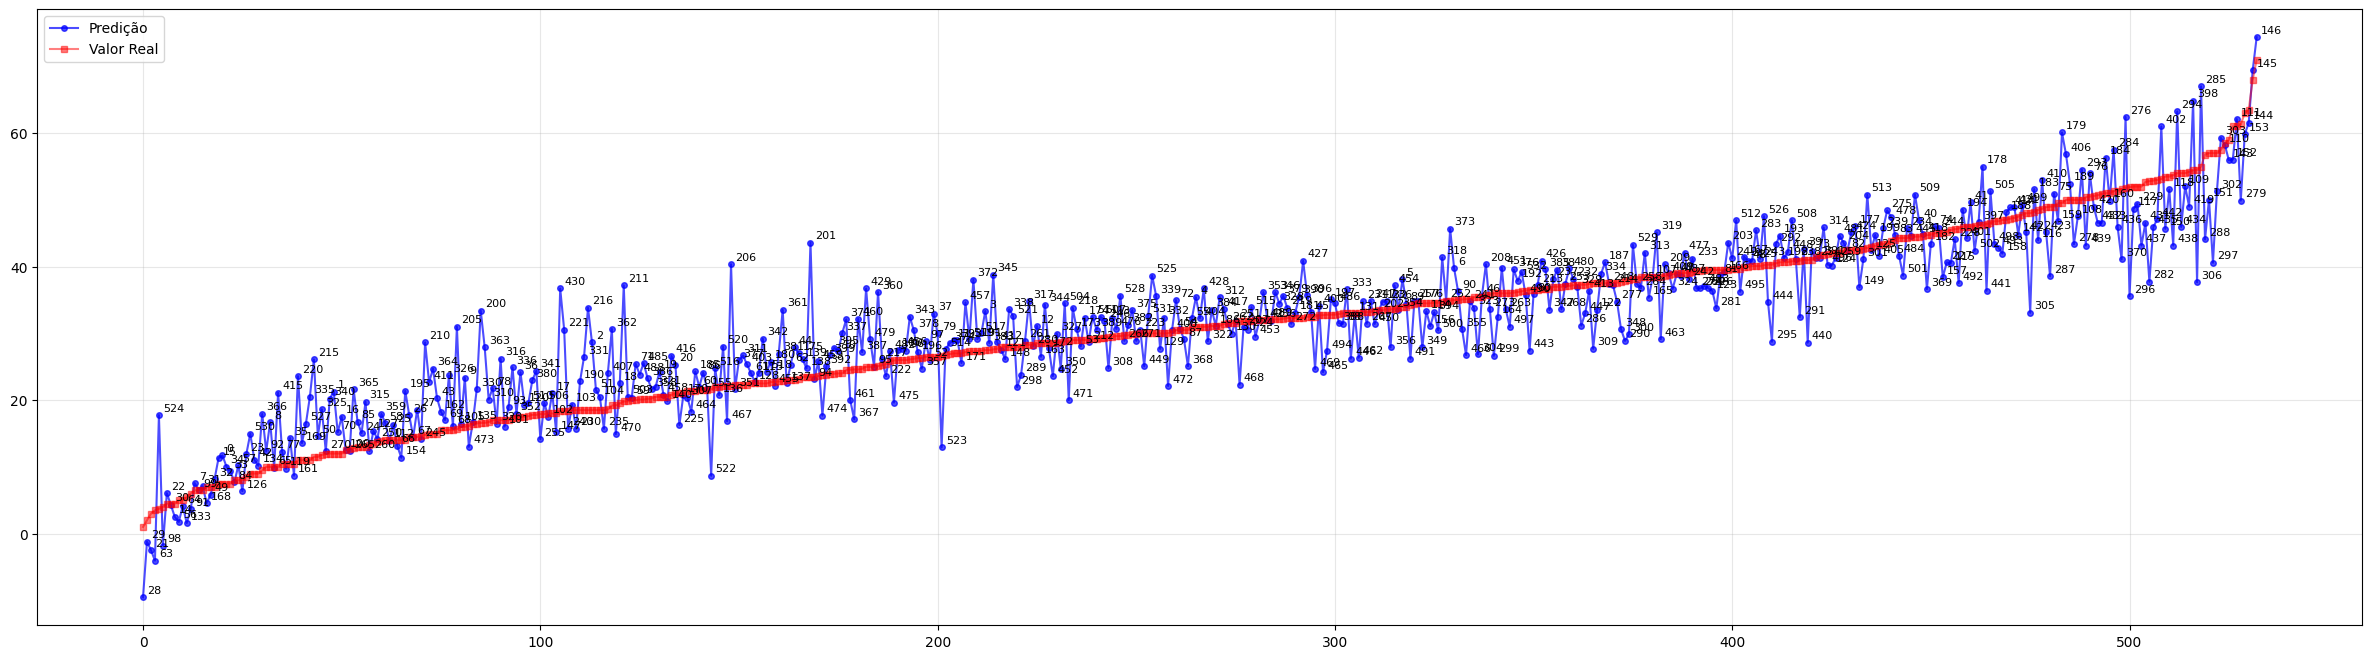

In [28]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = ridge_results.sort_values(by="y_true")
indices = range(len(debug_df))

plt.figure(figsize=(30, 8))

plt.plot(
    indices,
    debug_df["y_pred"],
    color='blue',
    label="Predição",
    alpha=0.7,
    linewidth=1.5,
    marker='o',
    markersize=4
)

plt.plot(
    indices,
    debug_df["y_true"],
    color='red',
    label="Valor Real",
    alpha=0.5,
    linewidth=1.5,
    marker='s',
    markersize=4
)

for x, y, idx in zip(
    indices,
    debug_df["y_pred"],
    debug_df.index
):
    plt.annotate(
        str(idx),
        (x, y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Distribuição dos residuos

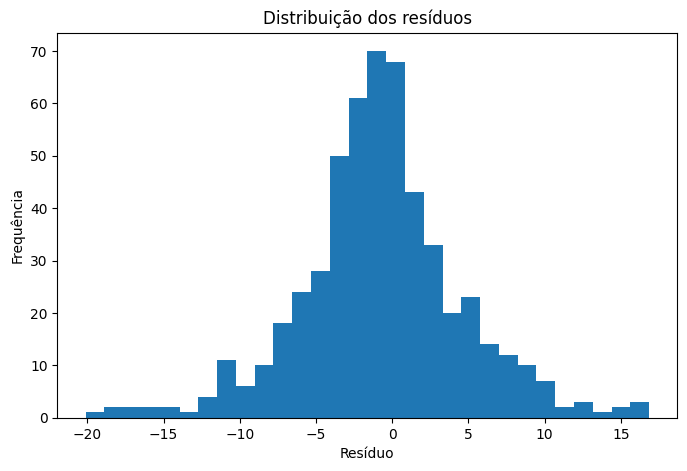

In [29]:
plt.figure(figsize=(8,5))

plt.hist(
    ridge_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

In [30]:
debug_df.columns

Index(['Finura_Cimento_Blaine_m2_kg', 'Agregado_Graudo_Total_kg_m3',
       'Relacao_Agua_Cimento', 'Tipo_Molde_Cod', 'cod_classe',
       'Massa_Esp_Cimento_kg_m3', 'Massa_Esp_Brita_kg_m3',
       'Massa_Esp_Filer_kg_m3', 'porosidade_volumetrica_inicial',
       'vol_po_total', 'pasta_agregado', 'indice_conformidade_feret',
       'pow_interacao_tempo', 'hasselman_cinetico', 's_fib',
       'pasta_agregado_fino', 'densidade_matriz', 'Autores/ano', 'vol_cimento',
       'vol_filer', 'Relacao_Agua_Aglomerante', 'vol_sp', 'target', 'y_true',
       'y_pred', 'error', 'abs_error', 'group', 'residual'],
      dtype='object')

## Residuo vs Predito

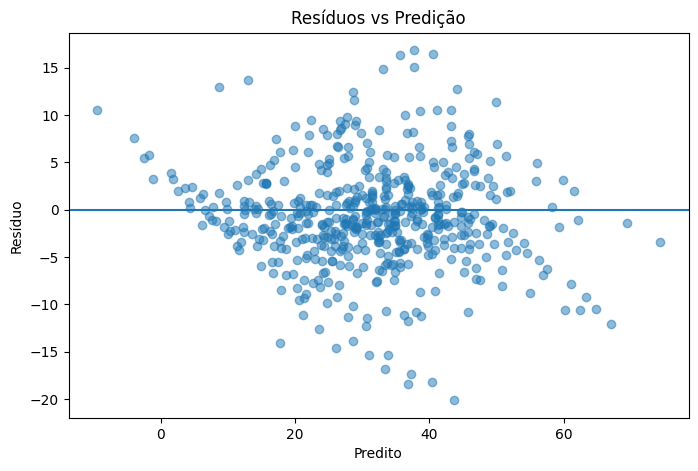

In [31]:
plt.figure(figsize=(8,5))

plt.scatter(
    ridge_results["y_pred"],
    ridge_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

## Erro Medio por grupo

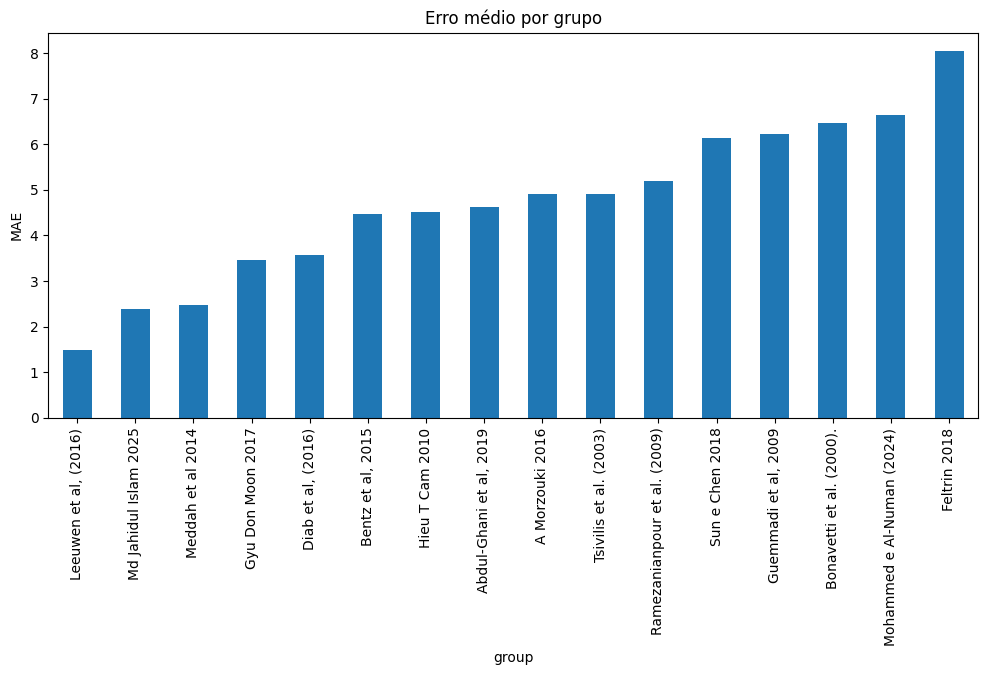

In [32]:
group_errors = (
    ridge_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [33]:
top_erros = (
    debug_df
    .query("abs_error > 15")
    .sort_values("abs_error", ascending=False)
)

display(top_erros)

,Finura_Cimento_Blaine_m2_kg,Agregado_Graudo_Total_kg_m3,Relacao_Agua_Cimento,Tipo_Molde_Cod,cod_classe,Massa_Esp_Cimento_kg_m3,Massa_Esp_Brita_kg_m3,Massa_Esp_Filer_kg_m3,porosidade_volumetrica_inicial,vol_po_total,...,vol_filer,Relacao_Agua_Aglomerante,vol_sp,target,y_true,y_pred,error,abs_error,group,residual
201,320.0,740.8,0.55,4,0,3210.00,2510.0,2690.000000,0.192500,0.109034,...,0.000000,0.55,0.000000,23.50,23.50,43.616277,-20.116277,20.116277,Ramezanianpour et al. (2009),-20.116277
430,381.0,1044.0,0.59,4,15,3121.25,2650.0,2876.250000,0.180000,0.130774,...,0.033377,0.45,0.000000,18.30,18.30,36.728718,-18.428718,18.428718,Sun e Chen 2018,-18.428718
206,320.0,738.7,0.58,4,0,3210.00,2510.0,2690.000000,0.192500,0.110088,...,0.006506,0.55,0.000000,22.17,22.17,40.366530,-18.196530,18.196530,Ramezanianpour et al. (2009),-18.196530
211,320.0,736.6,0.61,4,0,3210.00,2510.0,2690.000000,0.192500,0.111142,...,0.013011,0.55,0.000000,19.80,19.80,37.188547,-17.388547,17.388547,Ramezanianpour et al. (2009),-17.388547
306,350.0,1058.0,0.64,1,10,3090.00,2650.0,2890.000000,0.202469,0.118117,...,0.024913,0.51,0.000545,54.50,54.50,37.645244,16.854756,16.854756,Feltrin 2018,16.854756
200,320.0,740.8,0.55,4,0,3210.00,2510.0,2690.000000,0.192500,0.109034,...,0.000000,0.55,0.000000,16.60,16.60,33.402709,-16.802709,16.802709,Ramezanianpour et al. (2009),-16.802709
297,350.0,1058.0,0.60,1,10,3090.00,2650.0,2890.000000,0.202872,0.117714,...,0.018685,0.51,0.000545,57.00,57.00,40.581094,16.418906,16.418906,Feltrin 2018,16.418906
296,350.0,1058.0,0.60,1,10,3090.00,2650.0,2890.000000,0.202872,0.117714,...,0.018685,0.51,0.000545,51.90,51.90,35.548191,16.351809,16.351809,Feltrin 2018,16.351809
205,320.0,738.7,0.58,4,0,3210.00,2510.0,2690.000000,0.192500,0.110088,...,0.006506,0.55,0.000000,15.65,15.65,31.008492,-15.358492,15.358492,Ramezanianpour et al. (2009),-15.358492
216,320.0,734.5,0.65,4,0,3210.00,2510.0,2690.000000,0.192500,0.112196,...,0.019517,0.55,0.000000,18.50,18.50,33.830266,-15.330266,15.330266,Ramezanianpour et al. (2009),-15.330266


In [34]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 5.3922
mean_absolute_error: 3.9789
mean_absolute_percentage_error: 0.1986
R² Score: 83.6786


## Teste com ElasticNet

In [35]:
X = df_elasticnet.drop(
    columns=["target", "Autores/ano"]
)

y = df_elasticnet["target"]
groups = df_elasticnet["Autores/ano"]

def objective(trial):
    rmse_scores = []

    hyperparams = {
        "alpha": trial.suggest_float("alpha", 0.01, 10),
        "l1_ratio": trial.suggest_float("l1_ratio", 0.01, 1.0)
    }

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        model = ElasticNet(**hyperparams, random_state=42)

        model.fit(X_train, y_train)

        preds = model.predict(X_val)

        rmse = root_mean_squared_error(y_val, preds)
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)


In [36]:
# ==========================================
# EXECUTANDO O ESTUDO
# ==========================================
n_trials = 100

pbar = tqdm(total=n_trials, desc="Otimizando Regressão ElasticNet")

def tqdm_callback(study, trial):
    pbar.update(1)
    pbar.set_postfix({
        "best_rmse": f"{study.best_value:.4f}"
    })

study_elasticnet = optuna.create_study(
    direction="minimize",
    study_name="Tuning_Concreto"
)

study_elasticnet.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[tqdm_callback]
)

pbar.close()

print(f"Melhor RMSE alcançado (Cross-Validation): {study_elasticnet.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study_elasticnet.best_params.items():
    print(f"  '{key}': {value},")

Otimizando Regressão ElasticNet:   0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-11 13:49:05,330] A new study created in memory with name: Tuning_Concreto
[I 2026-06-11 13:49:05,482] Trial 0 finished with value: 5.683527305706469 and parameters: {'alpha': 2.1067881022731747, 'l1_ratio': 0.16408878359570997}. Best is trial 0 with value: 5.683527305706469.
[I 2026-06-11 13:49:05,607] Trial 1 finished with value: 7.811490270473277 and parameters: {'alpha': 6.1356420897139134, 'l1_ratio': 0.8378634747451977}. Best is trial 0 with value: 5.683527305706469.
[I 2026-06-11 13:49:05,729] Trial 2 finished with value: 5.497909478070916 and parameters: {'alpha': 1.2446064512805024, 'l1_ratio': 0.18097764346363138}. Best is trial 2 with value: 5.497909478070916.
[I 2026-06-11 13:49:05,852] Trial 3 finished with value: 5.855382862841369 and parameters: {'alpha': 1.9980764269379392, 'l1_ratio': 0.8911448087913825}. Best is trial 2 with value: 5.497909478070916.
[I 2026-06-11 13:49:05,970] Trial 4 finished with value: 6.072214308487128 and parameters: {'alpha': 2.790796

Melhor RMSE alcançado (Cross-Validation): 5.4008
Melhores Hiperparâmetros encontrados:
  'alpha': 0.1427375550650073,
  'l1_ratio': 0.03500274184885692,


In [37]:
all_preds = []
all_true = []
all_groups = []

X = df_elasticnet.drop(
    columns=["target", "Autores/ano"]
)

y = df_elasticnet["target"]
groups = df_elasticnet["Autores/ano"]

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = ElasticNet(**study_elasticnet.best_params, random_state=42)

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    all_preds.extend(preds)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])

In [38]:
elasticnet_results = pd.DataFrame({
    "y_true": all_true,
    "y_pred": all_preds,
    "group": all_groups
})

elasticnet_results["residual"] = (
    elasticnet_results["y_true"] -
    elasticnet_results["y_pred"]
)

elasticnet_results["abs_error"] = (
    elasticnet_results["residual"].abs()
)

## Observado vs Predito

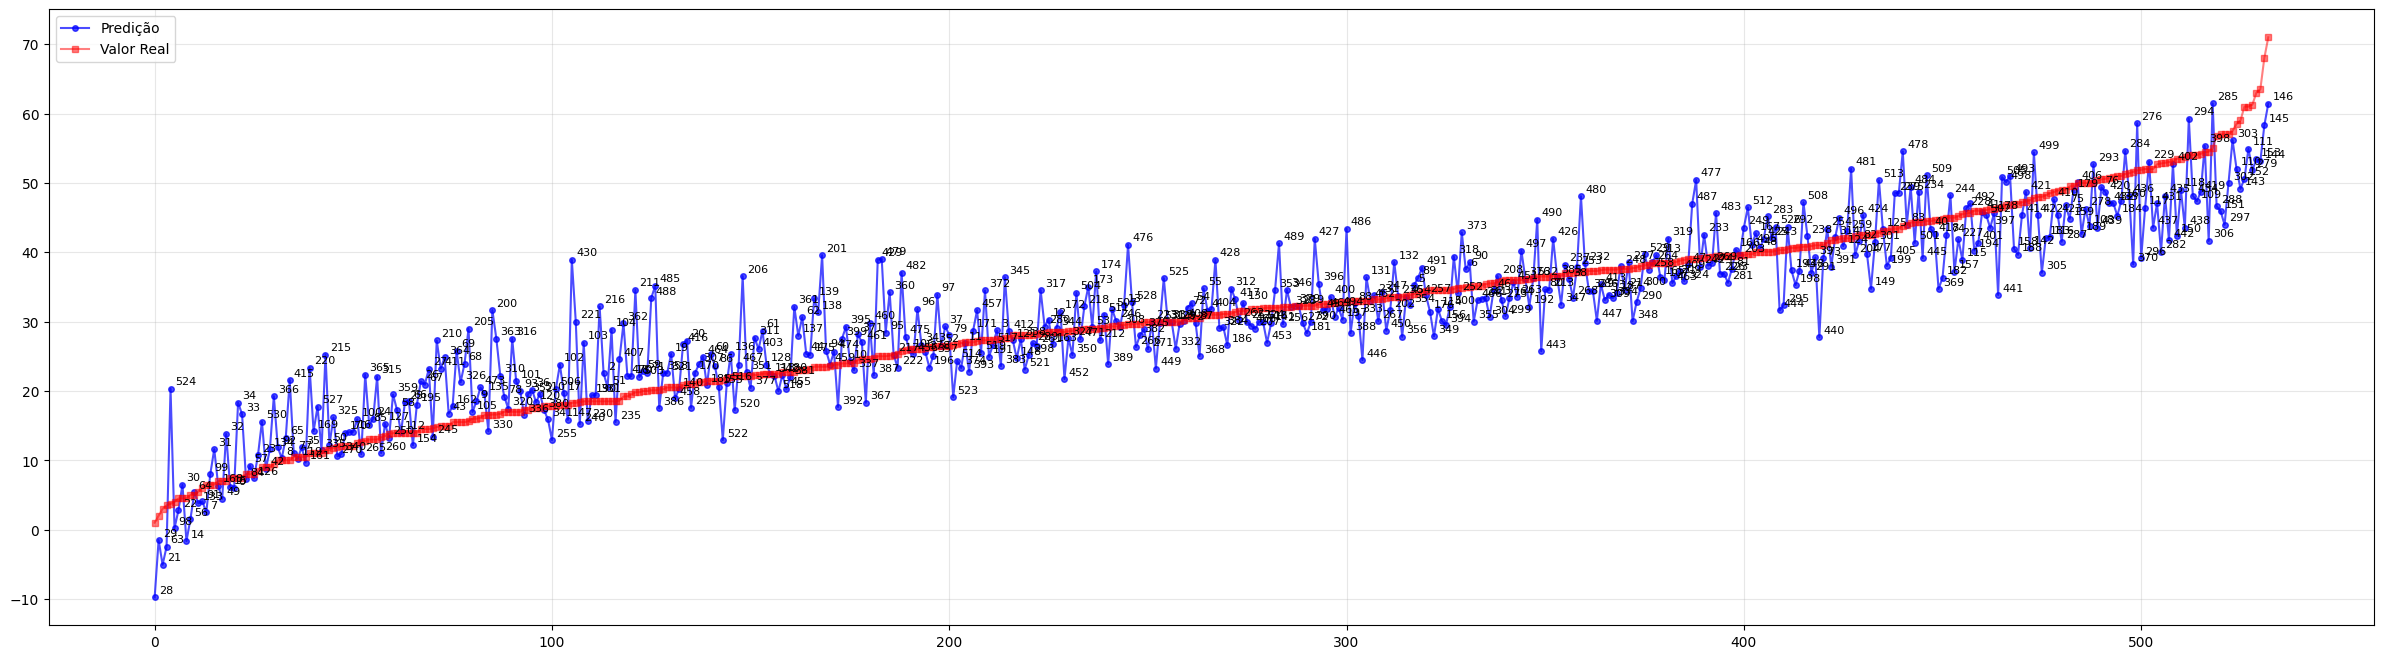

In [39]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = elasticnet_results.sort_values(by="y_true")
indices = range(len(debug_df))

plt.figure(figsize=(30, 8))

plt.plot(
    indices,
    debug_df["y_pred"],
    color='blue',
    label="Predição",
    alpha=0.7,
    linewidth=1.5,
    marker='o',
    markersize=4
)

plt.plot(
    indices,
    debug_df["y_true"],
    color='red',
    label="Valor Real",
    alpha=0.5,
    linewidth=1.5,
    marker='s',
    markersize=4
)

for x, y, idx in zip(
    indices,
    debug_df["y_pred"],
    debug_df.index
):
    plt.annotate(
        str(idx),
        (x, y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Distribuição dos residuos

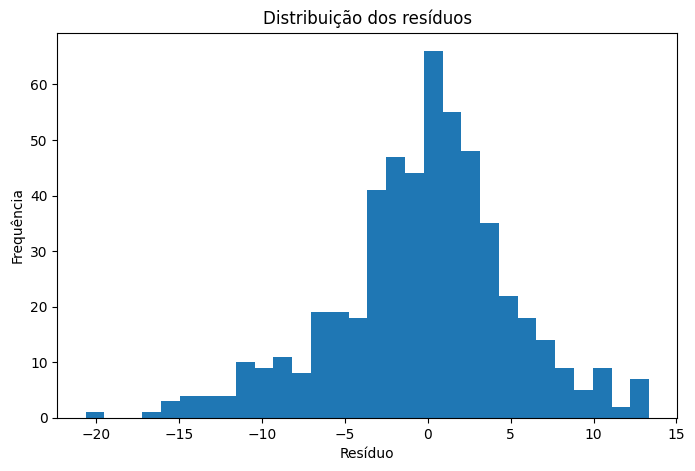

In [40]:
plt.figure(figsize=(8,5))

plt.hist(
    elasticnet_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

## Residuo vs Predito

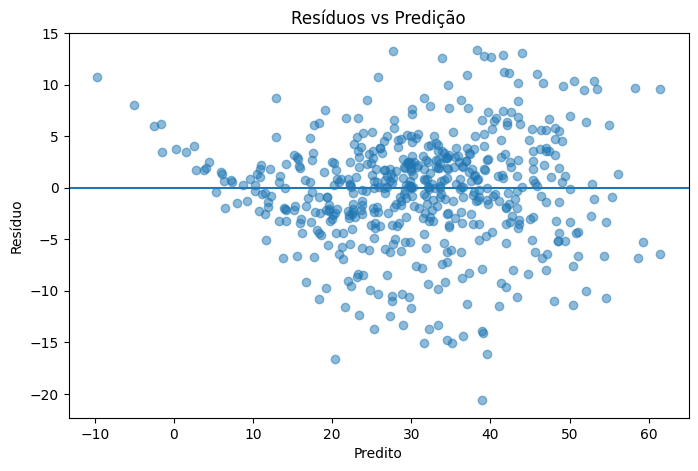

In [41]:
plt.figure(figsize=(8,5))

plt.scatter(
    elasticnet_results["y_pred"],
    elasticnet_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

## Erro Medio por grupo

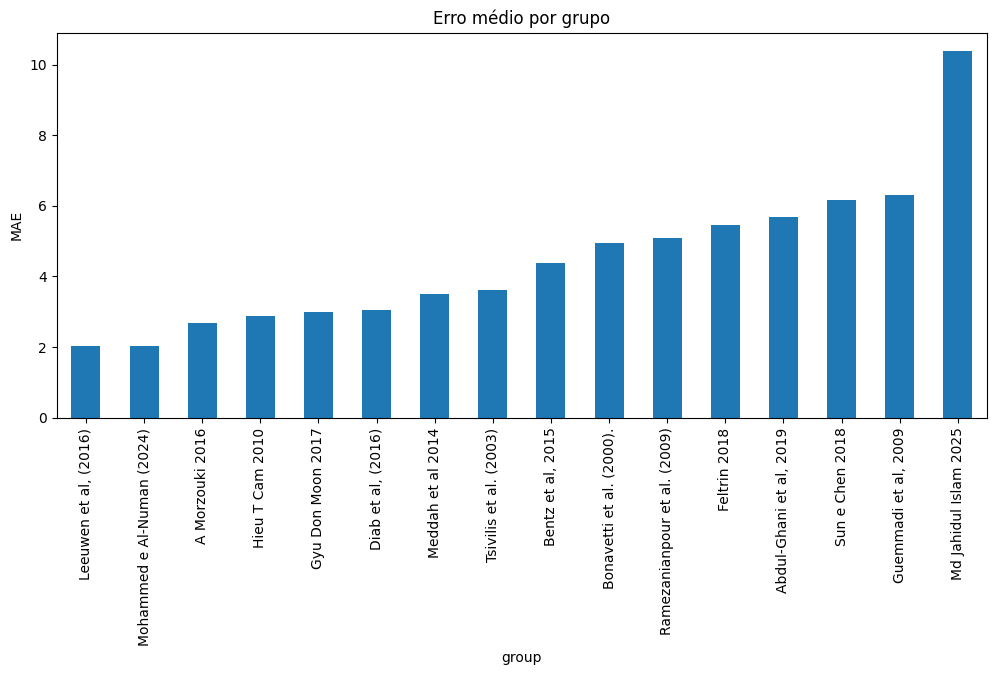

In [42]:
group_errors = (
    elasticnet_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [43]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 5.3924
mean_absolute_error: 4.0526
mean_absolute_percentage_error: 0.2055
R² Score: 83.6774
